# Crop Production Analysis using Machine Learning

This project analyzes agricultural production across India using machine learning techniques.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [7]:
# Load dataset
df = pd.read_csv("India Agriculture Crop Production.csv")

# View dataset
print(df.shape)
df.head()

(345407, 10)


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


In [8]:
# Dataset structure
df.info()

# Column names
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345407 entries, 0 to 345406
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   State             345407 non-null  object 
 1   District          345407 non-null  object 
 2   Crop              345375 non-null  object 
 3   Year              345407 non-null  object 
 4   Season            345406 non-null  object 
 5   Area              345374 non-null  float64
 6   Area Units        345407 non-null  object 
 7   Production        340414 non-null  float64
 8   Production Units  345407 non-null  object 
 9   Yield             345374 non-null  float64
dtypes: float64(3), object(7)
memory usage: 26.4+ MB
Index(['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Area Units',
       'Production', 'Production Units', 'Yield'],
      dtype='object')


In [9]:
# Remove missing values
df = df.dropna()

# Remove invalid values
df = df[(df['Area'] > 0) & (df['Production'] > 0)]

print("Cleaned shape:", df.shape)

Cleaned shape: (339390, 10)


In [10]:
# Create Yield feature
df['Yield'] = df['Production'] / df['Area']

# Log transformation (for better visualization and modeling)
df['Production_log'] = np.log1p(df['Production'])
df['Area_log'] = np.log1p(df['Area'])

In [11]:
# Convert categorical data into numeric
le = LabelEncoder()

df['Crop_enc'] = le.fit_transform(df['Crop'])
df['Season_enc'] = le.fit_transform(df['Season'])
df['State_enc'] = le.fit_transform(df['State'])

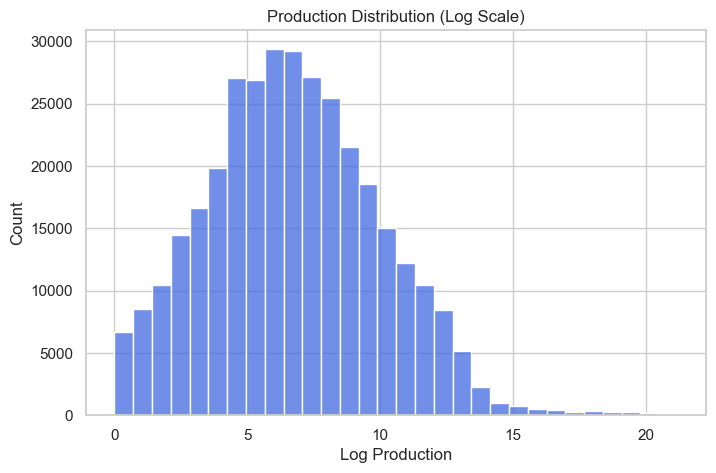

In [13]:
# Distribution of production
plt.figure(figsize=(8,5))
sns.histplot(df['Production_log'], bins=30, color='royalblue')
plt.title("Production Distribution (Log Scale)")
plt.xlabel("Log Production")
plt.show()

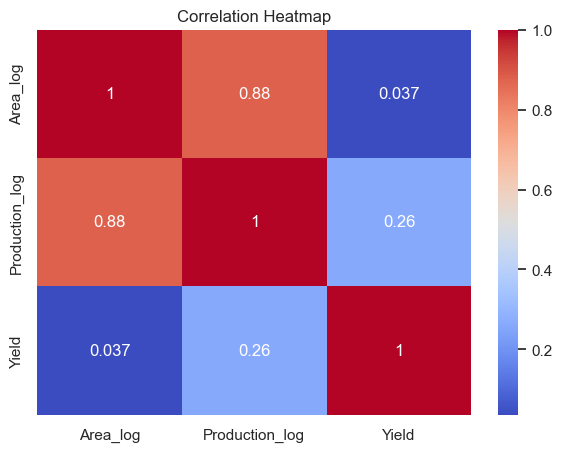

In [14]:
# Correlation between features
plt.figure(figsize=(7,5))
sns.heatmap(df[['Area_log','Production_log','Yield']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

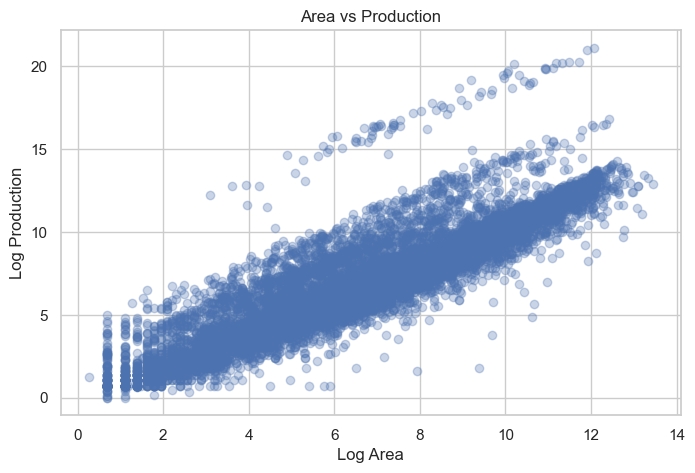

In [15]:
# Use sample for better visualization
sample_df = df.sample(n=10000, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(sample_df['Area_log'], sample_df['Production_log'], alpha=0.3)
plt.xlabel("Log Area")
plt.ylabel("Log Production")
plt.title("Area vs Production")
plt.show()

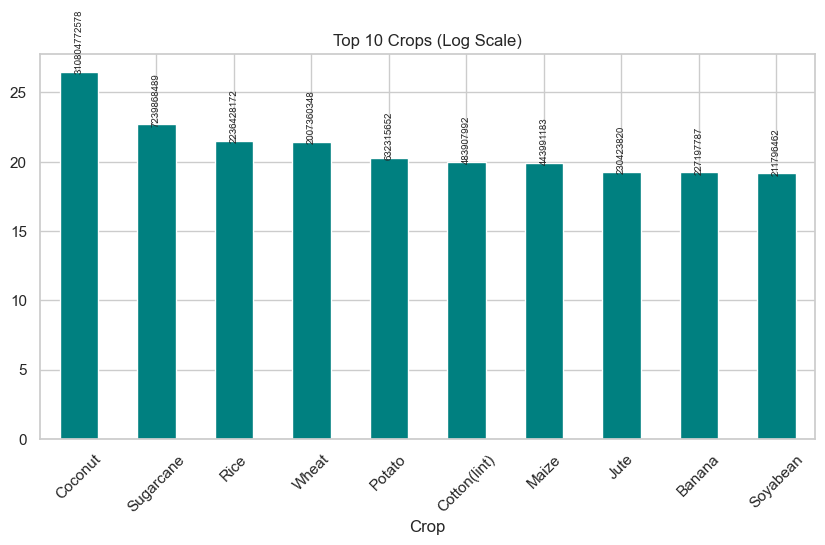

In [16]:
# Top crops
top_crops = df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_crops_log = np.log1p(top_crops)

ax = top_crops_log.plot(kind='bar', color='teal')

for i, v in enumerate(top_crops_log):
    ax.text(i, v, f'{int(top_crops.iloc[i])}', ha='center', fontsize=7, rotation=90)

plt.title("Top 10 Crops (Log Scale)")
plt.xticks(rotation=45)
plt.show()

C:\Users\PREM\AppData\Local\Temp\ipykernel_26748\1096094947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Production_log', data=df, palette='Set2')


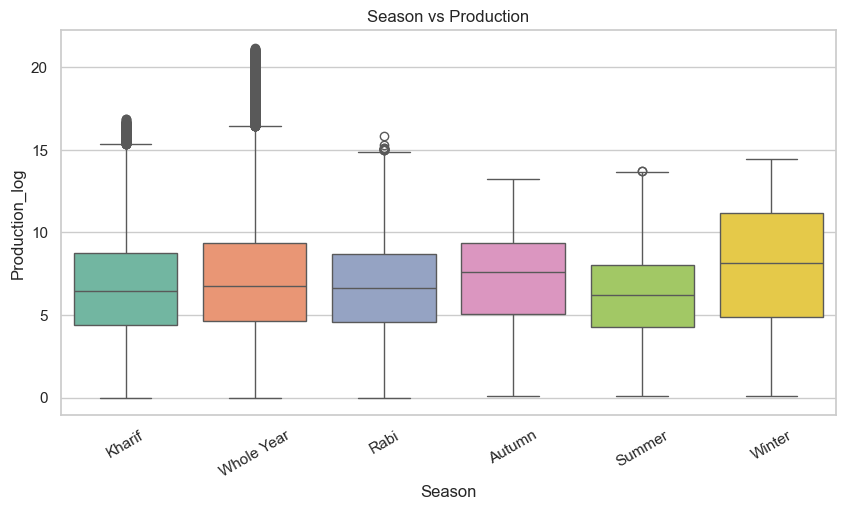

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Season', y='Production_log', data=df, palette='Set2')
plt.title("Season vs Production")
plt.xticks(rotation=30)
plt.show()

In [18]:
# Select features and target
X = df[['Area_log','Crop_enc','Season_enc','State_enc']]
y = df['Production_log']

In [19]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 1.006919976630717
R2: 0.7995434249641461


In [21]:
# Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 0.34282476024005404
R2: 0.9735203574197514


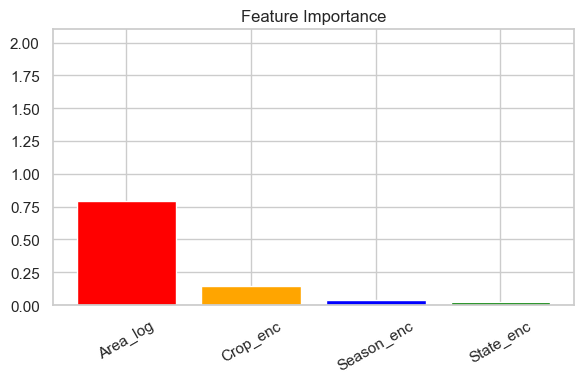

In [31]:
plt.figure(figsize=(6,4))
# ---- Right: Feature Importance ----
plt.plot(1,2,2)
importances = rf.feature_importances_

plt.bar(X.columns, importances, color=['red','orange','blue','green'])
plt.title("Feature Importance")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.barh(X.columns, importances, color='orange')
plt.title("Feature Importance")
plt.show()

In [23]:
# Create categories
df['Production_Level'] = pd.qcut(df['Production'], q=3, labels=['Low','Medium','High'])

X_cls = df[['Area_log','Crop_enc','Season_enc','State_enc']]
y_cls = df['Production_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7863961813842482
              precision    recall  f1-score   support

        High       0.84      0.83      0.83     22585
         Low       0.84      0.83      0.84     22545
      Medium       0.68      0.70      0.69     22748

    accuracy                           0.79     67878
   macro avg       0.79      0.79      0.79     67878
weighted avg       0.79      0.79      0.79     67878



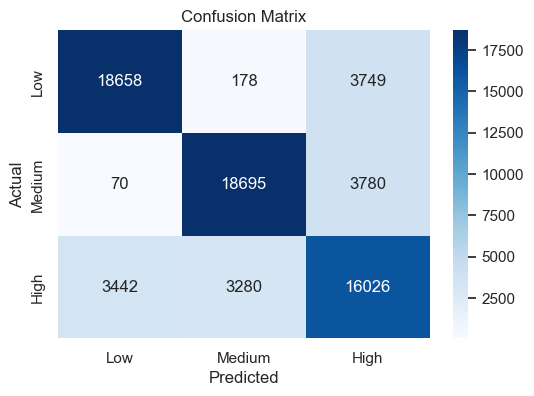

In [32]:
labels = ['Low','Medium','High']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Conclusion

- Production strongly depends on cultivated area  
- Few crops dominate agricultural output  
- Seasonal variation affects production  
- Random Forest provides best prediction performance  
- Classification helps in understanding production levels  